# E-Commerce Customer Intelligence & Sales Analytics
**Author:** Prathamesh Jadhav
**Submission for:** BharatCares

---

## 1. Project Overview & Business Problem
The objective of this project is to analyze historical e-commerce transaction data to uncover actionable insights regarding sales performance, geographic distribution, product intelligence, and customer segmentation. The business problem is to identify strategies that can increase customer retention, optimize product offerings, and drive sustainable revenue growth.

## 2. Dataset Overview
The dataset contains transactional data for a UK-based online retail company. It includes attributes such as Invoice Number, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country.

## 3. Data Audit Summary
During the initial audit, we identified missing CustomerIDs, negative quantities (returns/cancellations), and non-standard StockCodes indicating postage or manual adjustments. A significant portion of transactions lacked customer identification, representing a sizable chunk of gross revenue.

## 4. Data Cleaning Summary
The cleaning process involved:
- Removing duplicates.
- Categorizing transaction types (Sales vs. Returns).
- Classifying non-product codes (e.g., Postage, Bank Charges).
- Handling missing CustomerIDs where possible or isolating them to prevent skewed customer-level analysis.

## 5. Executive KPIs


In [1]:
import pandas as pd
from IPython.display import Image, display

# Load and display Executive KPIs
yearly_kpis = pd.read_csv('outputs/yearly_kpis.csv')
display(yearly_kpis)


,year,gross_revenue,return_value,net_revenue,return_value_abs,orders,units,unique_customers,average_order_value,gross_revenue_yoy_pct,net_revenue_yoy_pct,orders_yoy_pct,units_yoy_pct
0,2009,779111.76,-19388.33,759723.43,19388.33,1661,419892,950,469.061866,NaN,NaN,NaN,NaN
1,2010,9674795.03,-240446.62,9434348.41,240446.62,19615,5706666,4205,493.234516,1141.772429,1141.813539,1080.915111,1259.079478
2,2011,9369409.61,-456086.50,8913323.11,456086.50,18216,5167299,4213,514.350550,-3.156505,-5.522642,-7.132297,-9.451526


## 6. Sales & Revenue Intelligence
The sales trend indicates significant seasonality with peaks towards the year-end holiday season.


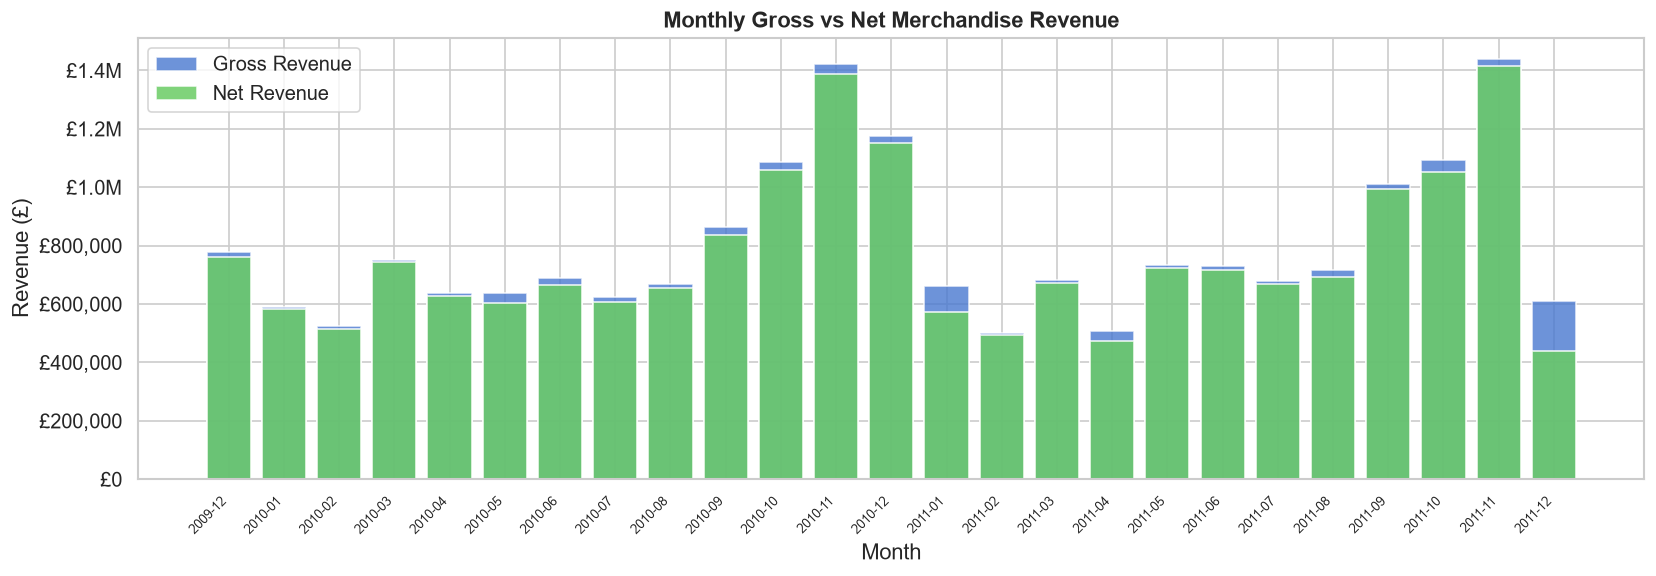

In [2]:
# Assuming a monthly revenue plot was generated in notebook 04
import os
img_path = 'outputs/figures/18_monthly_gross_net_revenue.png'
if os.path.exists(img_path):
    display(Image(filename=img_path))
else:
    print("Sales trend figure available in earlier notebook outputs.")


## 7. Product Intelligence
Certain products drive a disproportionate amount of net revenue. Identifying these top-performing products helps optimize inventory and promotional strategies.


,StockCode,canonical_description,total_units_sold,gross_revenue,number_of_orders,number_of_customers,return_value,net_revenue
1628,22423,REGENCY CAKESTAND 3 TIER,27536.0,344069.30,3918.0,1314.0,-16724.10,327345.20
4278,85123A,WHITE HANGING HEART T-LIGHT HOLDER,96027.0,262768.47,5365.0,1490.0,-9389.65,253378.82
4250,85099B,JUMBO BAG RED RETROSPOT,98175.0,183136.14,3989.0,978.0,-2176.32,180959.82
3127,47566,PARTY BUNTING,28362.0,149109.35,2674.0,894.0,-1238.55,147870.80
3970,84879,ASSORTED COLOUR BIRD ORNAMENT,81590.0,131817.81,2807.0,1010.0,-774.07,131043.74
1322,22086,PAPER CHAIN KIT 50'S CHRISTMAS,36534.0,123002.89,2018.0,896.0,-1479.40,121523.49
3420,79321,CHILLI LIGHTS,16763.0,85157.56,1135.0,304.0,-635.75,84521.81
1429,22197,SMALL POPCORN HOLDER,89860.0,80888.34,2322.0,601.0,-620.57,80267.77
1597,22386,JUMBO BAG PINK POLKADOT,39809.0,77049.38,2245.0,601.0,-866.98,76182.40
3573,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,32498.0,74380.07,756.0,300.0,-634.20,73745.87


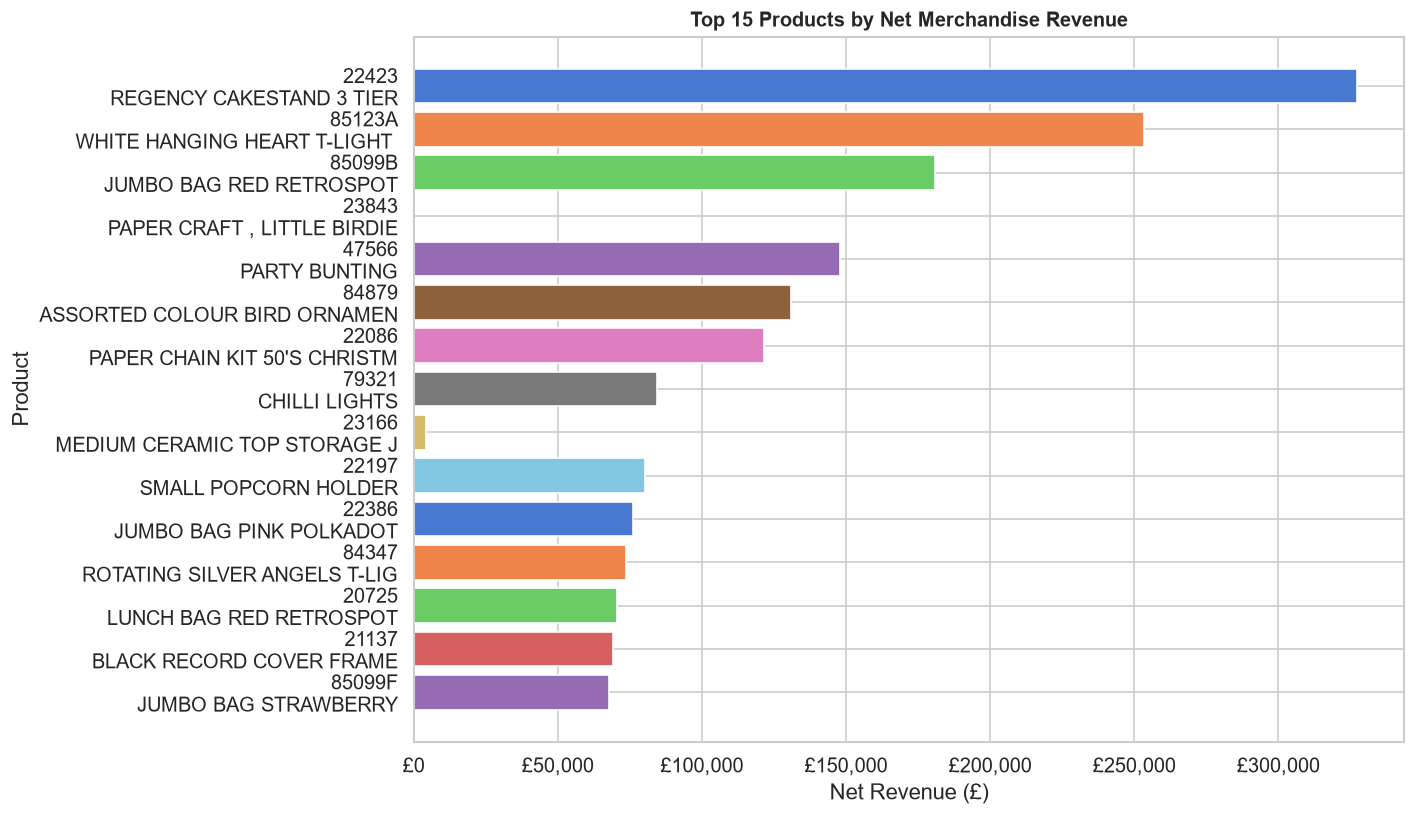

In [3]:
product_summary = pd.read_csv('outputs/product_summary.csv')
display(product_summary.sort_values(by='net_revenue', ascending=False).head(10))

img_path = 'outputs/figures/31_top15_products_net_revenue.png'
if os.path.exists(img_path):
    display(Image(filename=img_path))


## 8. Geographic Intelligence
The United Kingdom represents the vast majority of transactions and revenue. However, specific international markets exhibit higher average order values (AOV).


,Country,gross_revenue,orders,units_sold,unique_customers,return_value,net_revenue,average_order_value,revenue_per_customer
0,United Kingdom,16982530.79,36162,9274695,5334,-631606.86,16350923.93,469.623660,3183.826545
1,EIRE,618850.75,581,336647,3,-20233.10,598617.65,1065.147590,206283.583333
2,Netherlands,547882.96,216,383086,22,-3677.98,544204.98,2536.495185,24903.770909
3,Germany,382453.24,752,223590,107,-8835.38,373617.86,508.581436,3574.329346
4,France,311893.53,598,272142,93,-17635.24,294258.29,521.561087,3353.693871
5,Australia,166052.56,89,103402,15,-1512.91,164539.65,1865.759101,11070.170667
7,Switzerland,93740.03,85,52516,22,-1106.53,92633.50,1102.823882,4260.910455
6,Spain,98248.76,144,50272,38,-12955.19,85293.57,682.283056,2585.493684
8,Sweden,84885.44,99,88089,19,-1973.97,82911.47,857.428687,4467.654737
9,Denmark,68466.59,42,237804,12,-4067.10,64399.49,1630.156905,5705.549167


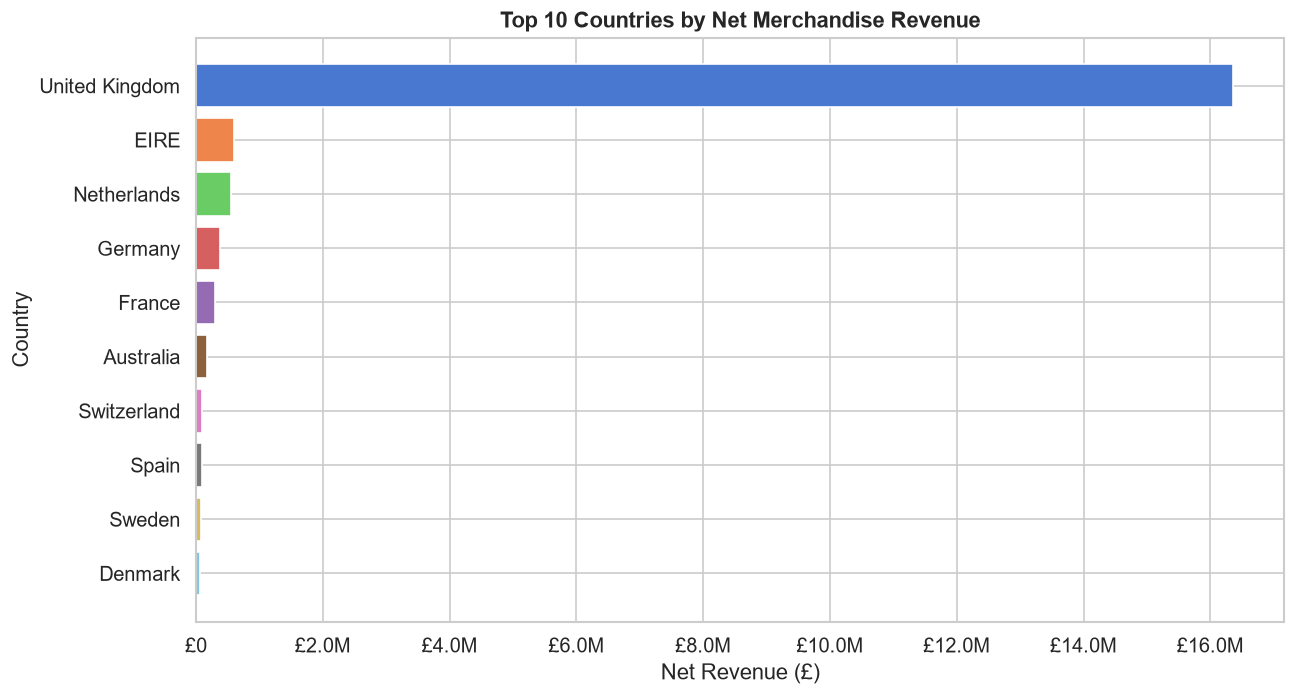

In [4]:
country_summary = pd.read_csv('outputs/country_summary.csv')
display(country_summary.sort_values(by='net_revenue', ascending=False).head(10))

img_path = 'outputs/figures/25_top10_countries.png'
if os.path.exists(img_path):
    display(Image(filename=img_path))


## 9. Customer Intelligence
Customer lifetime value and order frequency vary significantly. A large portion of revenue is generated by a relatively small segment of highly loyal customers.


In [5]:
customer_summary = pd.read_csv('outputs/customer_summary.csv')
display(customer_summary.describe())


,customer_id,total_orders,total_units,total_revenue,unique_products,average_order_value,customer_lifetime_days
count,5851.000000,5851.000000,5851.000000,5851.000000,5851.000000,5851.000000,5851.000000
mean,15319.344215,6.251239,1809.298752,2936.335987,81.557341,385.628978,273.460434
std,1714.851785,12.746246,8919.076219,14395.153078,115.585158,1253.538765,258.452155
min,12346.000000,1.000000,1.000000,2.950000,1.000000,2.950000,0.000000
25%,13837.500000,1.000000,190.000000,341.265000,19.000000,177.376333,0.000000
50%,15320.000000,3.000000,489.000000,868.480000,44.000000,279.770000,223.000000
75%,16801.500000,7.000000,1367.000000,2254.115000,102.000000,412.447500,511.000000
max,18287.000000,373.000000,366447.000000,595861.930000,2523.000000,84236.250000,738.000000


## 10. RFM Analysis
We used the Recency, Frequency, and Monetary (RFM) methodology.
- **Recency**: Days since last purchase compared to snapshot date.
- **Frequency**: Total orders placed.
- **Monetary**: Total revenue generated.
Customers were assigned a score from 1-5 for each metric (using quintiles), creating a composite `RFM_Score`.


In [6]:
segments = pd.read_csv('outputs/customer_segments.csv')
display(segments[['customer_id', 'Recency', 'Frequency', 'Monetary', 'RFM_Segment', 'RFM_Score']].head(10))


,customer_id,Recency,Frequency,Monetary,RFM_Segment,RFM_Score
0,12346.0,325,3,77347.01,235,10
1,12347.0,2,8,5633.32,545,14
2,12348.0,75,5,1658.40,344,11
3,12349.0,18,3,3678.69,535,13
4,12350.0,310,1,294.40,212,5
5,12351.0,375,1,270.33,211,4
6,12352.0,36,9,1709.74,454,13
7,12353.0,204,2,406.76,222,6
8,12354.0,232,1,1079.40,213,6
9,12355.0,214,2,947.61,223,7


## 11. K-Means Customer Segmentation
To discover natural groupings, we applied K-Means clustering to the log-transformed and standardized RFM features. 
**K Selection**: K=4 was chosen to yield highly interpretable and actionable distinct customer profiles (e.g., Champions, Loyal Customers, At-Risk, and Lost).

### Cluster Profile Table:


Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0          27.4       3.0    841.5  1229
1         221.9       5.2   2012.4  1479
2          26.6      19.4  10829.9  1157
3         390.7       1.4    322.1  1986

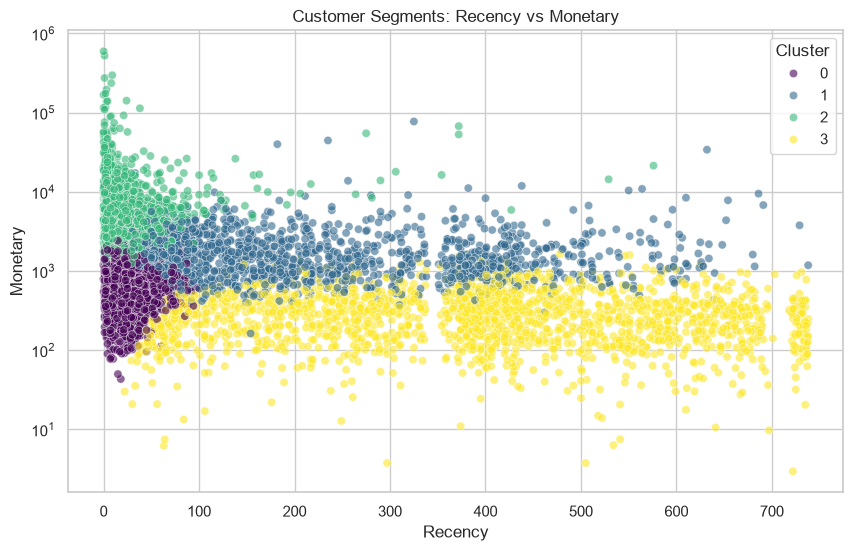

In [7]:
cluster_profile = segments.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)
display(cluster_profile)

img_path = 'outputs/figures/52_kmeans_clusters.png'
if os.path.exists(img_path):
    display(Image(filename=img_path))


## 12. Integrated Business Insights
- **Concentration Risk**: High reliance on the UK market and a small group of VIP customers.
- **Returns Impact**: A few specific products have excessively high return rates affecting net profitability.
- **Engagement**: K-Means clustering highlights that re-engaging "At-Risk" segments could unlock substantial trapped value.

## 13. Strategic Recommendations
1. **VIP Retention**: Launch exclusive loyalty programs for Cluster 3 (high Frequency/Monetary).
2. **International Expansion**: Allocate marketing budget to top international regions with high AOV (e.g., EIRE, Germany).
3. **Product Quality Control**: Investigate and resolve the high return rates for the most returned StockCodes.
4. **Re-engagement Campaigns**: Target the "At-Risk" and "Lost" clusters with win-back discount campaigns.

## 14. Conclusion
The comprehensive analysis of e-commerce data transitioned raw transaction logs into actionable customer and product intelligence. By leveraging RFM and K-Means segmentation, the business can shift from generic marketing to highly targeted, data-driven strategies that optimize lifetime value and mitigate revenue leakage.
